#### Decision Tree Regressor

    The main aim of this project is to predict the price of the house using Decision Tree Regressor with the help of California Housing dataset.

#### Aim of this Project:---

(i.)  We need to contruct the decision tree

(ii.) Then we need to predict the price of the house for a given sample data


#### Step 1:  Import  all the necessary libraries

In [703]:
import  numpy               as  np
import  pandas              as  pd
import  matplotlib.pyplot   as  plt
import  seaborn             as  sns

from    sklearn.datasets        import  fetch_california_housing
from    sklearn.model_selection import  train_test_split,   GridSearchCV,   KFold
from    sklearn.preprocessing   import  StandardScaler
from    sklearn.pipeline        import  Pipeline
from    sklearn.tree            import  DecisionTreeRegressor, plot_tree
from    sklearn.metrics         import  mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

#### Step 2: Load the dataset

In [704]:
#### extract the data

data = fetch_california_housing(as_frame=True)

#### Construct the dataframe from the data

df = pd.DataFrame(data.data, columns = data.feature_names)

#### Add the target to the dataframe

df['MedHouseVal'] = data.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


#### OBSERVATIONS:

1.  The above dataset explains about the house price details of California for each and every record.

2.  The independent features in the dataset are as follows :----

    (a.)  MedInc ===============>  Median Income

    (b.)  HouseAge =============>  Median House Age

    (c.)  AveRooms =============>  Average number of rooms per household

    (d.)  Population ============> Total population in a district

    (e.)  AveOccup ==============>  Average Occupation per household

    (f.)  Latitude ==============>  Geographical Latitude

    (g.)  Longitude ==============> Geographical longitude

3. The dependent feature of the dataset is MedHouseVal

    (a.)  MedHouseVal =============> Median House Value (House Price)

#### Step 3:    Perform the Data Exploration

In [705]:
#### get the top five rows of the dataset

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [706]:
#### get the bottom five rows of the dataset

df.tail()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847
20639,2.3886,16.0,5.254717,1.162264,1387.0,2.616981,39.37,-121.24,0.894


In [707]:
#### get the length of the dataset

print("Length of the dataset is:", len(df))

Length of the dataset is: 20640


In [708]:
#### get the shape of the dataset

print("Shape of the dataset is:", df.shape)

Shape of the dataset is: (20640, 9)


In [709]:
#### get the columns used in the dataset

df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')

In [710]:
#### get the information about the columns in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


#### OBSERVATIONS:

1.  All the columns in the dataset is floating point in nature.

In [711]:
#### get the descriptive summary statistics about the columns used in the dataset

df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


#### OBSERVATIONS:

1.  The above dataset explains about the descriptive summary about every numerical column in the dataset.

In [712]:
#### get the correlation between all the columns used in the dataset

df.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


<Axes: >

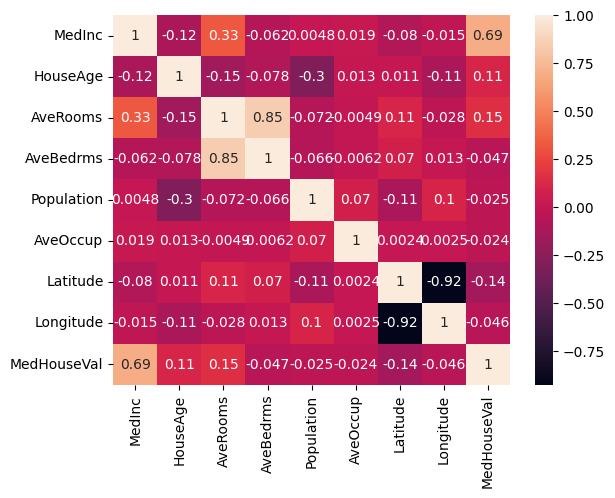

In [713]:
#### get the graphical  representation for the correlation between all the columns used in the dataset

sns.heatmap(df.corr(),annot=True)

#### OBSERVATIONS:

1.  The above dataset explains about the graphical representation for the correlation between the columns used in the dataset.

#### Step 4: Perform Data Cleaning and Feature Engineering

In [714]:
#### To check for the NULL records used in the dataset

df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

#### OBSERVATIONS:

1.  There are no NULL records used in the dataset.

In [715]:
#### To check for the duplicate records used in the dataset

df[df.duplicated()]

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal


#### OBSERVATIONS:

1.  There are no duplicate records used in the dataset.

#### Step 5:    Divide the dataset into independent and dependent features

In [716]:
#### independent features

X = df.drop(columns='MedHouseVal',axis=1)

print(X)

       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  
0        -122.23  
1

In [717]:
#### dependent features

Y = df['MedHouseVal']

In [718]:
print(Y)

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: MedHouseVal, Length: 20640, dtype: float64


#### Step 6: Divide the independent and dependent features into training and testing data

In [719]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [720]:
X_train

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
14196,3.2596,33.0,5.017657,1.006421,2300.0,3.691814,32.71,-117.03
8267,3.8125,49.0,4.473545,1.041005,1314.0,1.738095,33.77,-118.16
17445,4.1563,4.0,5.645833,0.985119,915.0,2.723214,34.66,-120.48
14265,1.9425,36.0,4.002817,1.033803,1418.0,3.994366,32.69,-117.11
2271,3.5542,43.0,6.268421,1.134211,874.0,2.300000,36.78,-119.80
...,...,...,...,...,...,...,...,...
11284,6.3700,35.0,6.129032,0.926267,658.0,3.032258,33.78,-117.96
11964,3.0500,33.0,6.868597,1.269488,1753.0,3.904232,34.02,-117.43
5390,2.9344,36.0,3.986717,1.079696,1756.0,3.332068,34.03,-118.38
860,5.7192,15.0,6.395349,1.067979,1777.0,3.178891,37.58,-121.96


In [721]:
X_test

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
20046,1.6812,25.0,4.192201,1.022284,1392.0,3.877437,36.06,-119.01
3024,2.5313,30.0,5.039384,1.193493,1565.0,2.679795,35.14,-119.46
15663,3.4801,52.0,3.977155,1.185877,1310.0,1.360332,37.80,-122.44
20484,5.7376,17.0,6.163636,1.020202,1705.0,3.444444,34.28,-118.72
9814,3.7250,34.0,5.492991,1.028037,1063.0,2.483645,36.62,-121.93
...,...,...,...,...,...,...,...,...
15362,4.6050,16.0,7.002212,1.066372,1351.0,2.988938,33.36,-117.22
16623,2.7266,28.0,6.131915,1.256738,1650.0,2.340426,35.36,-120.83
18086,9.2298,25.0,7.237676,0.947183,1585.0,2.790493,37.31,-122.05
2144,2.7850,36.0,5.289030,0.983122,1227.0,2.588608,36.77,-119.76


In [722]:
print("Shape of the input training data is:", X_train.shape)
print("Shape of the input testing  data is:", X_test.shape)

Shape of the input training data is: (16512, 8)
Shape of the input testing  data is: (4128, 8)


In [723]:
Y_train

14196    1.030
8267     3.821
17445    1.726
14265    0.934
2271     0.965
         ...  
11284    2.292
11964    0.978
5390     2.221
860      2.835
15795    3.250
Name: MedHouseVal, Length: 16512, dtype: float64

In [724]:
Y_test

20046    0.47700
3024     0.45800
15663    5.00001
20484    2.18600
9814     2.78000
          ...   
15362    2.63300
16623    2.66800
18086    5.00001
2144     0.72300
3665     1.51500
Name: MedHouseVal, Length: 4128, dtype: float64

In [725]:
print("Shape of the output training data is:", Y_train.shape)
print("Shape of the output testing  data is:", Y_test.shape)

Shape of the output training data is: (16512,)
Shape of the output testing  data is: (4128,)


#### Step 7:  Perform Feature Scaling on the inputs

In [726]:
from sklearn.preprocessing  import  StandardScaler

#### create an object for Standard Scaler

sc = StandardScaler()

#### using the object for Standard Scaler, transform the inputs

X_train_scaled = sc.fit_transform(X_train)

X_test_scaled  = sc.transform(X_test)

In [727]:
X_train_scaled

array([[-0.326196  ,  0.34849025, -0.17491646, ...,  0.05137609,
        -1.3728112 ,  1.27258656],
       [-0.03584338,  1.61811813, -0.40283542, ..., -0.11736222,
        -0.87669601,  0.70916212],
       [ 0.14470145, -1.95271028,  0.08821601, ..., -0.03227969,
        -0.46014647, -0.44760309],
       ...,
       [-0.49697313,  0.58654547, -0.60675918, ...,  0.02030568,
        -0.75500738,  0.59946887],
       [ 0.96545045, -1.07984112,  0.40217517, ...,  0.00707608,
         0.90651045, -1.18553953],
       [-0.68544764,  1.85617335, -0.85144571, ..., -0.08535429,
         0.99543676, -1.41489815]])

In [728]:
X_test_scaled

array([[-1.15508475, -0.28632369, -0.52068576, ...,  0.06740798,
         0.1951    ,  0.28534728],
       [-0.70865905,  0.11043502, -0.16581537, ..., -0.03602975,
        -0.23549054,  0.06097472],
       [-0.21040155,  1.85617335, -0.61076476, ..., -0.14998876,
         1.00947776, -1.42487026],
       ...,
       [ 2.80902421, -0.28632369,  0.75501156, ..., -0.02646898,
         0.78014149, -1.23041404],
       [-0.57542978,  0.58654547, -0.06124296, ..., -0.04390537,
         0.52740357, -0.08860699],
       [-0.17259111, -0.92113763, -0.6058703 , ...,  0.05466644,
        -0.66608108,  0.60445493]])

#### OBSERVATIONS:

1.  Here all the input features have been transformed in the same scale between -1 to 1

#### Step 8: Train the Decision Tree Regressor Model

In [729]:
from sklearn.tree import DecisionTreeRegressor

#### create an object for DecisionTreeRegressor

decreg = DecisionTreeRegressor(
    random_state = 42
)

#### using the object of Decision Tree Regressor, train the model
decreg.fit(X_train_scaled, Y_train)

DecisionTreeRegressor(random_state=42)

#### Step 9: Predict the Model

In [730]:
Y_pred = decreg.predict(X_test_scaled)

In [731]:
Y_pred

array([0.414  , 1.203  , 5.00001, ..., 5.00001, 0.66   , 2.172  ])

#### Step 10: Evaluate the Regression Metrics

In [732]:
from    sklearn.metrics             import   mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

print("==============================Mean Absolute Error========================================================")

mae = mean_absolute_error(Y_test, Y_pred)

print("Mean Absolute Error of the model is:", mae)


print("==============================Mean Squared Error========================================================")

mse = mean_squared_error(Y_test, Y_pred)

print("Mean Squared Error of the model is:", mse)


print("==============================Root Mean Squared Error========================================================")

rmse = root_mean_squared_error(Y_test, Y_pred)

print("Root Mean Squared Error of the model is:", rmse)


print("==============================R2 Score========================================================")

r2 = r2_score(Y_test, Y_pred)

print("R2 Score of the model is:", r2)

==============================Mean Absolute Error========================================================
Mean Absolute Error of the model is: 0.45390448401162786
==============================Mean Squared Error========================================================
Mean Squared Error of the model is: 0.49396854311945243
==============================Root Mean Squared Error========================================================
Root Mean Squared Error of the model is: 0.7028289572288925
==============================R2 Score========================================================
R2 Score of the model is: 0.6230424613065773


#### OBSERVATIONS:

1.  The R2 Score of the Decison Tree Regressor Model using California Housing dataset is 0.62.

2.  The R2 Score is very high, but it can further be improved using Hyper Parameter Tuning using GridSerachCV

#### Step 11: Predict the House Price for a given sample data

In [733]:
df.iloc[[0]]

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.02381,322.0,2.555556,37.88,-122.23,4.526


In [734]:
X.iloc[[0]]

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.02381,322.0,2.555556,37.88,-122.23


In [735]:
#### define the sample data

sample = X.iloc[[0]]

#### perform the scaling on the sample data

scaled_data = sc.transform(sample)

print(scaled_data)

#### perform the prediction on the scaled data

prediction = decreg.predict(scaled_data)

print("Predicted House Price of the dataset is:", prediction)

[[ 2.33397811  0.98330419  0.64880421 -0.1682248  -0.97135592 -0.04676
   1.04692041 -1.32016306]]
Predicted House Price of the dataset is: [3.822]


#### Step 12: Plot the Decision Tree Regressor

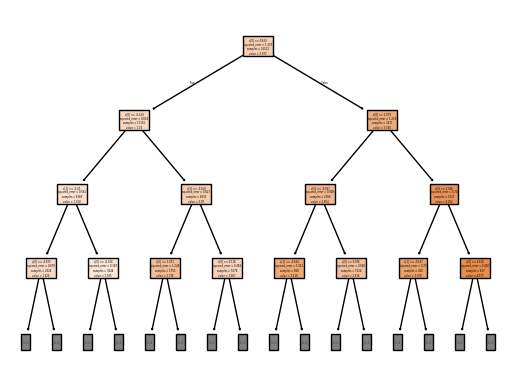

In [736]:
from sklearn.tree import plot_tree

plot_tree(decreg, filled=True, max_depth=3)

plt.show()

#### Step 13: Perform Hyper Parameter Tuning with GridSearchCV

In [737]:
#### define the pipeline

from sklearn.pipeline import Pipeline

#### craete an object for pipeline

pipeline = Pipeline([
    ("sc"       ,   StandardScaler())   ,
    ("decreg"   ,   DecisionTreeRegressor())
])

In [738]:
#### define the parameter grid

param_grid = {
    "decreg__criterion"         :   ["squared_error"    ,   "friedman_mse"]         ,
    "decreg__max_depth"         :   [3,5,10,15,20]                                  ,
    "decreg__min_samples_split" :   [2,5,10]                                        ,
    "decreg__min_samples_leaf"  :   [1,2,4]                                         ,
    "decreg__max_features"      :   [None,"sqrt","log2"]    
}

In [739]:
#### perform the KFold validation

cv = KFold(n_splits=5, shuffle=True, random_state=42)

In [740]:
#### create an object for GridSearchCV

grid = GridSearchCV(
    pipeline                                  ,
    param_grid      =       param_grid        ,
      cv            =          cv             ,
      scoring       =       'r2'              ,
      n_jobs        =         -1
)

In [741]:
#### using the object of GridSearchCV, train the model

grid.fit(X_train, Y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('sc', StandardScaler()),
                                       ('decreg', DecisionTreeRegressor())]),
             n_jobs=-1,
             param_grid={'decreg__criterion': ['squared_error', 'friedman_mse'],
                         'decreg__max_depth': [3, 5, 10, 15, 20],
                         'decreg__max_features': [None, 'sqrt', 'log2'],
                         'decreg__min_samples_leaf': [1, 2, 4],
                         'decreg__min_samples_split': [2, 5, 10]},
             scoring='r2')

In [742]:
#### Obtain the best parameter and estimator for the model

best_parameter = grid.best_params_
print("Best Parameter for the model is:", best_parameter)

best_estimator = grid.best_estimator_
print("Best Estimator for the model is:", best_estimator)


Best Parameter for the model is: {'decreg__criterion': 'squared_error', 'decreg__max_depth': 10, 'decreg__max_features': None, 'decreg__min_samples_leaf': 4, 'decreg__min_samples_split': 10}
Best Estimator for the model is: Pipeline(steps=[('sc', StandardScaler()),
                ('decreg',
                 DecisionTreeRegressor(max_depth=10, min_samples_leaf=4,
                                       min_samples_split=10))])


In [743]:
#### predict the model

Y_pred_grid = best_estimator.predict(X_test)

In [744]:
Y_pred_grid

array([0.53276375, 0.72655118, 4.96858   , ..., 4.98150941, 0.72655118,
       1.69809149])

In [745]:
##### Evaluate the Regression Metrics

from    sklearn.metrics             import   mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score


print("==============================Mean Absolute Error========================================================")

maegrid = mean_absolute_error(Y_test, Y_pred_grid)

print("Mean Absolute Error of the model is:", maegrid)



print("==============================Mean Squared Error========================================================")

msegrid = mean_squared_error(Y_test, Y_pred_grid)

print("Mean Squared Error of the model is:", msegrid)



print("==============================Root Mean Squared Error========================================================")

rmsegrid = root_mean_squared_error(Y_test, Y_pred_grid)

print("Root Mean Squared Error of the model is:", rmsegrid)


print("==============================R2 Score========================================================")

r2grid = r2_score(Y_test, Y_pred_grid)

print("R2 Score of the model is:", r2grid)

==============================Mean Absolute Error========================================================
Mean Absolute Error of the model is: 0.431405281939361
==============================Mean Squared Error========================================================
Mean Squared Error of the model is: 0.40821255941073803
==============================Root Mean Squared Error========================================================
Root Mean Squared Error of the model is: 0.6389151425742999
==============================R2 Score========================================================
R2 Score of the model is: 0.6884846134382223


#### OBSERVATIONS:

1.  The R2 Score of the Decision Tree Regressor Model using Caliornia Housing dataset is 0.68 after performing hyperparameter with GridSearchCV.

2.  The R2 Score has improved from 0.62 to 0.68 using Hyper Parameter Tuning using GridSerachCV. So the model is completely fine.

#### Step 14: Predict the House Price for a given sample data after performing hyper parameter tuning with GridSearchCV

In [746]:
#### define the sample data

sample = X.iloc[[0]]

#### perform the prediction on the scaled data

prediction = best_estimator.predict(sample)

print("Predicted House Price of the dataset is:", prediction)

Predicted House Price of the dataset is: [4.2145]


#### Step 15: Plot the Decision Tree Regressor ater performing Hyper Parameter Tuning with GridSearchCV

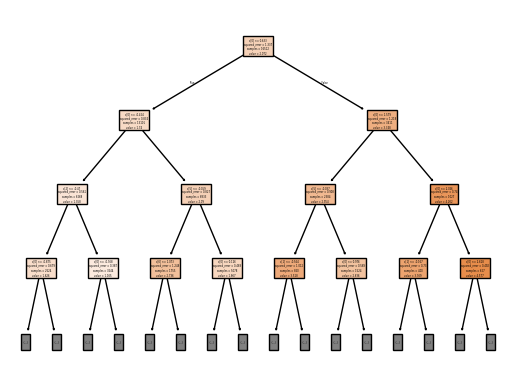

In [747]:
# Extract the trained Decision Tree model

best_model = best_estimator.named_steps["decreg"]

plot_tree(best_model, filled=True, max_depth=3)

plt.show()